In [162]:
print("LETS START WITH EDA")

LETS START WITH EDA


In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder



In [164]:
df=pd.read_csv('../data/amazonSale.csv',encoding='latin-1')
df = df.drop(columns=['Column1'])
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Order Date     9994 non-null   object 
 2   Ship Date      9994 non-null   object 
 3   Ship Mode      9994 non-null   object 
 4   Customer ID    9994 non-null   object 
 5   Customer Name  9994 non-null   object 
 6   Segment        9994 non-null   object 
 7   Country        9994 non-null   object 
 8   City           9994 non-null   object 
 9   State          9994 non-null   object 
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   object 
 12  Product ID     9994 non-null   object 
 13  Category       9994 non-null   object 
 14  Sub-Category   9994 non-null   object 
 15  Product Name   9994 non-null   object 
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount

In [166]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [167]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [168]:
df.columns.tolist()

['Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [169]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [170]:
print(df['State'].nunique())
print(df['City'].nunique())

49
531


In [171]:
df['Ship Date']

0       11-11-2016
1       11-11-2016
2       16-06-2016
3       18-10-2015
4       18-10-2015
           ...    
9989    23-01-2014
9990    03-03-2017
9991    03-03-2017
9992    03-03-2017
9993    09-05-2017
Name: Ship Date, Length: 9994, dtype: object

In [172]:
df['Order Date']

0       08-11-2016
1       08-11-2016
2       12-06-2016
3       11-10-2015
4       11-10-2015
           ...    
9989    21-01-2014
9990    26-02-2017
9991    26-02-2017
9992    26-02-2017
9993    04-05-2017
Name: Order Date, Length: 9994, dtype: object

In [173]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [174]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [175]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [176]:
for i in range(0, len(df.columns)):
    print(f"{df.columns[i]}: {df.iloc[:, i].nunique()} unique values")

Order ID: 5009 unique values
Order Date: 1237 unique values
Ship Date: 1334 unique values
Ship Mode: 4 unique values
Customer ID: 793 unique values
Customer Name: 793 unique values
Segment: 3 unique values
Country: 1 unique values
City: 531 unique values
State: 49 unique values
Postal Code: 631 unique values
Region: 4 unique values
Product ID: 1862 unique values
Category: 3 unique values
Sub-Category: 17 unique values
Product Name: 1850 unique values
Sales: 5825 unique values
Quantity: 14 unique values
Discount: 12 unique values
Profit: 7287 unique values


In [177]:
numerical_cols=[]
categorical_cols=[]
for i in range(len(df.columns)):
    if df.iloc[:, i].dtype in ['int64', 'float64']:
        numerical_cols.append(df.columns[i])
    else:
        categorical_cols.append(df.columns[i])
        
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']
Categorical Columns: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']


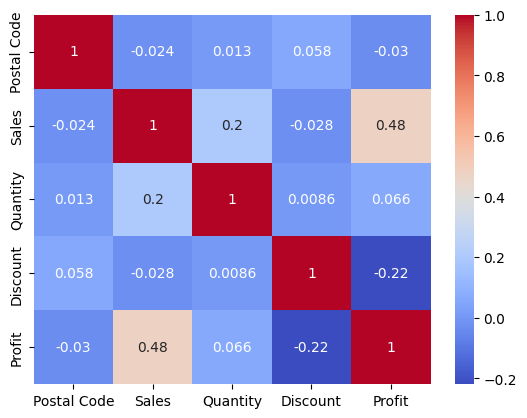

In [178]:

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [179]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [180]:
print(df['Ship Date'].dtype)
print(df['Order Date'].dtype)

datetime64[ns]
datetime64[ns]


In [181]:
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month
df['shipping_days'] = (df['Ship Date'] - df['Order Date']).dt.days
df.drop(columns=['Order Date','Ship Date'], inplace=True)

In [182]:
city_freq = df['City'].value_counts()
df['City_freq'] = df['City'].map(city_freq)

state_freq = df['State'].value_counts()
df['State_freq'] = df['State'].map(state_freq)

df.drop(columns=['City','State'], inplace=True)

In [183]:
df["Sales_per_Item"] = df["Sales"] / df["Quantity"]
df["Discount_Impact"] = df["Discount"] * df["Sales"]

In [184]:
df.drop(columns=[
# 'Order ID',
# 'Customer ID',
'Customer Name',
'Product ID',
'Product Name',
'Country',
'Postal Code'
], inplace=True)

In [185]:
numerical_cols=[]
categorical_cols=[]
for i in range(len(df.columns)):
    if df.iloc[:, i].dtype in ['int64', 'float64']:
        numerical_cols.append(df.columns[i])
    else:
        categorical_cols.append(df.columns[i])
        
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Sales', 'Quantity', 'Discount', 'Profit', 'shipping_days', 'City_freq', 'State_freq', 'Sales_per_Item', 'Discount_Impact']
Categorical Columns: ['Order ID', 'Ship Mode', 'Customer ID', 'Segment', 'Region', 'Category', 'Sub-Category', 'order_year', 'order_month']


In [186]:
for i in range(0, len(df.columns)):
    print(f"{df.columns[i]}: {df.iloc[:, i].nunique()} unique values")

Order ID: 5009 unique values
Ship Mode: 4 unique values
Customer ID: 793 unique values
Segment: 3 unique values
Region: 4 unique values
Category: 3 unique values
Sub-Category: 17 unique values
Sales: 5825 unique values
Quantity: 14 unique values
Discount: 12 unique values
Profit: 7287 unique values
order_year: 4 unique values
order_month: 12 unique values
shipping_days: 8 unique values
City_freq: 70 unique values
State_freq: 45 unique values
Sales_per_Item: 3298 unique values
Discount_Impact: 3446 unique values


In [187]:
total_spend=df['Sales'].sum()
print(f"Total Spend: {total_spend}")

Total Spend: 2297200.8603000003


In [188]:
avg_order_value=df['Sales'].mean()
total_quantity=df['Quantity'].sum()
avg_discount=df['Discount'].mean()
total_profit=df['Profit'].sum()
order_frequency=df.shape[0]

print(f"Average Order Value: {avg_order_value}")
print(f"Total Quantity Sold: {total_quantity}")     
print(f"Average Discount: {avg_discount}")
print(f"Total Profit: {total_profit}")
print(f"Order Frequency: {order_frequency}")   

Average Order Value: 229.85800083049833
Total Quantity Sold: 37873
Average Discount: 0.15620272163297977
Total Profit: 286397.0217
Order Frequency: 9994


In [189]:
customer_df = df.groupby("Customer ID").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum",
    "Discount": "mean",
    "Order ID": "nunique"
}).reset_index()

customer_df.rename(columns={"Order ID": "Total_Orders"}, inplace=True)

In [190]:
customer_df["Avg_Order_Value"] = customer_df["Sales"] / customer_df["Total_Orders"]
customer_df["Profit_per_Order"] = customer_df["Profit"] / customer_df["Total_Orders"]
customer_df["Items_per_Order"] = customer_df["Quantity"] / customer_df["Total_Orders"]

In [191]:

X = customer_df[[
    "Sales",
    "Profit",
    "Quantity",
    "Discount",
    "Total_Orders",
    "Avg_Order_Value"
]]

In [192]:
X.to_csv('../data/new_amazon_sales.csv', index=False)

In [193]:
cols = ['Ship Mode','Segment','Region','Category','Sub-Category']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cols)
    ],
    remainder='passthrough'
)
    

In [194]:
df_encoded = preprocessor.fit_transform(df)

feature_names = preprocessor.get_feature_names_out()

df_encoded = pd.DataFrame(df_encoded, columns=feature_names)

df_encoded = df_encoded.drop(
    columns=['remainder__Order ID','remainder__Customer ID']
)

In [195]:
df_encoded.shape

(9994, 37)

In [196]:
df_encoded.head()

,cat__Ship Mode_Same Day,cat__Ship Mode_Second Class,cat__Ship Mode_Standard Class,cat__Segment_Corporate,cat__Segment_Home Office,cat__Region_East,cat__Region_South,cat__Region_West,cat__Category_Office Supplies,cat__Category_Technology,...,remainder__Quantity,remainder__Discount,remainder__Profit,remainder__order_year,remainder__order_month,remainder__shipping_days,remainder__City_freq,remainder__State_freq,remainder__Sales_per_Item,remainder__Discount_Impact
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2,0.0,41.9136,2016,11,3,51,139,130.98,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3,0.0,219.582,2016,11,3,51,139,243.98,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,2,0.0,6.8714,2016,6,4,747,2001,7.31,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,5,0.45,-383.031,2015,10,7,15,383,191.5155,430.909875
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,2,0.2,2.5164,2015,10,7,15,383,11.184,4.4736


In [197]:
df_encoded.shape
df_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   cat__Ship Mode_Same Day        9994 non-null   object
 1   cat__Ship Mode_Second Class    9994 non-null   object
 2   cat__Ship Mode_Standard Class  9994 non-null   object
 3   cat__Segment_Corporate         9994 non-null   object
 4   cat__Segment_Home Office       9994 non-null   object
 5   cat__Region_East               9994 non-null   object
 6   cat__Region_South              9994 non-null   object
 7   cat__Region_West               9994 non-null   object
 8   cat__Category_Office Supplies  9994 non-null   object
 9   cat__Category_Technology       9994 non-null   object
 10  cat__Sub-Category_Appliances   9994 non-null   object
 11  cat__Sub-Category_Art          9994 non-null   object
 12  cat__Sub-Category_Binders      9994 non-null   object
 13  cat

In [198]:
df_encoded.to_csv('../data/modified_amazon_sales.csv', index=False)